### Low-Rank Optimal Transport via Factor Relaxation with Latent Coupling (FRLC)
This notebook provides a tutorial on the FRLC algorithm introduced by Halmos et al. (NeurIPS 2024).  The objective is to utilize OTT-JAX low-level primitives to solve low-rank optimal transport using a latent coupling factorization.  

### 1. Imports and Configuration

In [1]:
!pip install jax jaxlib ott-jax matplotlib numpy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 90.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 97.0 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 94.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 83.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 94.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 97.3 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18/18 [ott-jax]7/18 [ott-jax]ib]


In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

# Imports from local package
from FRLC_solver import run_frlc, compute_lc_projections, draw_transport_plan

# JAX Configuration
print("Device used:", jax.devices())

Device used: [CpuDevice(id=0)]


### 2. Algorithm Overview
FRLC minimizes the primal transport cost $L(\mathbf{Q}, \mathbf{R}, \mathbf{T})$ based on the latent coupling factorization:  $$L(\mathbf{Q}, \mathbf{R}, \mathbf{T}) = \langle \mathbf{C}, \mathbf{Q} \mathbf{X} \mathbf{R}^\top \rangle_F$$where the latent matrix $\mathbf{X}$ links sub-couplings via two distinct inner marginals $\mathbf{g}_Q$ and $\mathbf{g}_R$:  $$\mathbf{X} = \operatorname{diag}(1/\mathbf{g}_Q) \, \mathbf{T} \, \operatorname{diag}(1/\mathbf{g}_R)$$The optimization is performed via block coordinate mirror descent, alternating between updating the factors $(\mathbf{Q}, \mathbf{R})$ and the latent coupling $\mathbf{T}$.  

### 3. Experiment: Mass Transfer (Two Moons to 8 Gaussians)
We will generate synthetic data to illustrate the performance and interpretability of the model.

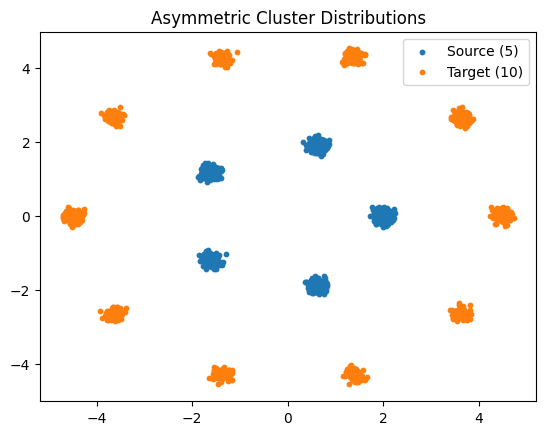

In [3]:
def generate_roots_of_unity(n, k, radius=2.0):
    """Sample n points from k Gaussians arranged in a circle."""
    angles = jnp.linspace(0, 2*jnp.pi, k, endpoint=False)
    centers = radius * jnp.stack([jnp.cos(angles), jnp.sin(angles)], axis=1)
    key = jax.random.PRNGKey(42)
    idx = jax.random.randint(key, (n,), 0, k)
    noise = 0.1 * jax.random.normal(key, (n, 2))
    return centers[idx] + noise

N = 1000
# 5 Source clusters vs 10 Target clusters
z_src = generate_roots_of_unity(N, k=5, radius=2.0)
z_tgt = generate_roots_of_unity(N, k=10, radius=4.5)

# Compute normalized Cost Matrix
C = jnp.linalg.norm(z_src[:, None, :] - z_tgt[None, :, :], axis=-1)
C /= C.max()

plt.scatter(z_src[:, 0], z_src[:, 1], s=10, label="Source (5)")
plt.scatter(z_tgt[:, 0], z_tgt[:, 1], s=10, label="Target (10)")
plt.legend()
plt.title("Asymmetric Cluster Distributions")
plt.show()

### 3. Solving with FRLC
We use a rank $r=5$. Since the target has 10 clusters, FRLC must use its full $r \times r$ coupling $\mathbf{T}$ to map each source cluster to multiple target clusters.

In [ ]:
Q, R, T, costs = run_frlc(
    C, 
    rank=5, 
    tau=60.0, 
    gamma=80.0, 
    max_outer=150, 
    return_costs=True
)

print(f"Optimization finished. Final Primal Cost: {costs[-1]:.5f}")

Optimization finished. Final Primal Cost: 0.40140


### 4. Visualizing Interpretability
One of the major advantages of FRLC is the $\mathbf{T}$ matrix, which represents the flows between latent clusters. We use the functions from utils.py here.  

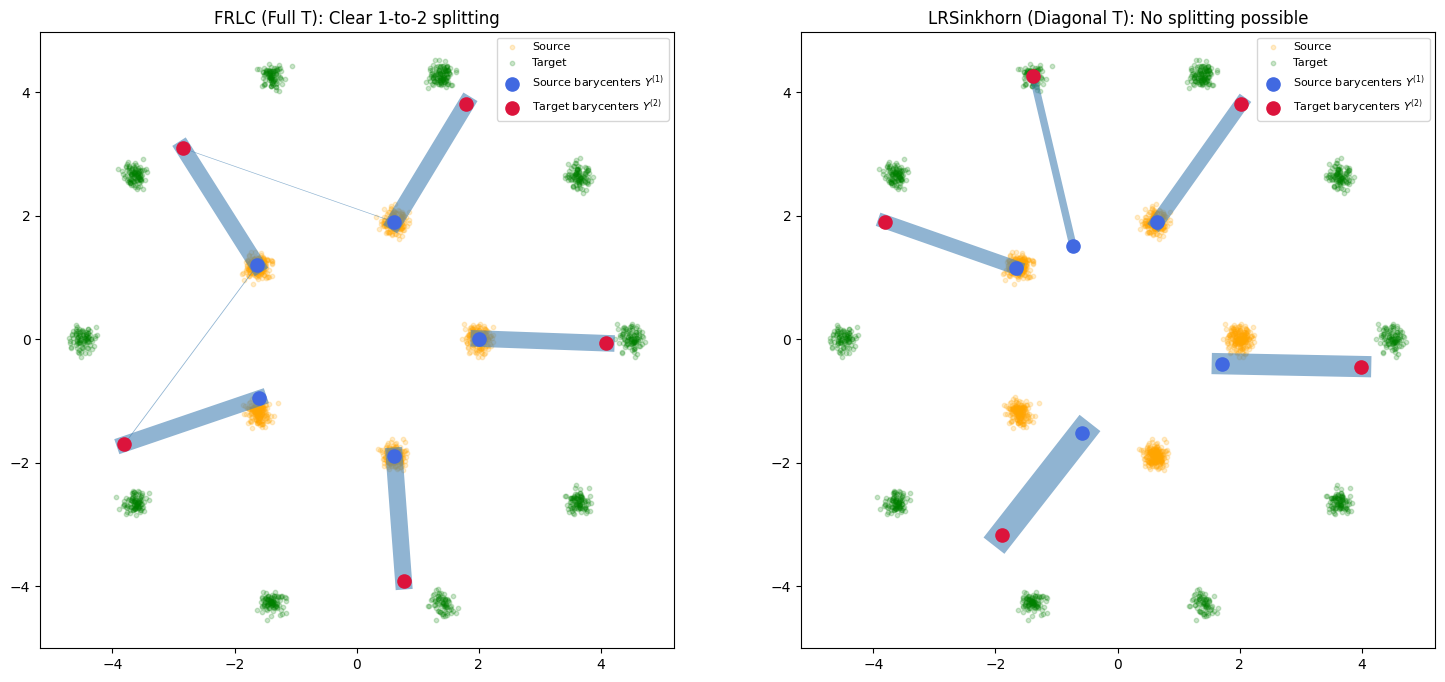

In [10]:
from ott.solvers.linear import sinkhorn_lr
from ott.geometry.geometry import Geometry
from ott.problems.linear import linear_problem

# 1. Solve via LRSinkhorn (Standard Low-Rank OT)
geom_lr = Geometry(cost_matrix=C, epsilon=1e-2)
prob_lr = linear_problem.LinearProblem(geom_lr, a=jnp.ones(N)/N, b=jnp.ones(N)/N)
out_lr = sinkhorn_lr.LRSinkhorn(rank=5, max_iterations=500)(prob_lr)

# 2. Extract factors (Fixed: using .q and .r attributes)
Q_lr = out_lr.q
R_lr = out_lr.r
# For LRSinkhorn, the latent coupling is strictly a diagonal matrix
T_lr = jnp.diag(out_lr.g) 

# 3. Compute projections for visualization
Y_src_lr, Y_tgt_lr = compute_lc_projections(z_src, z_tgt, Q_lr, R_lr)

# 4. Comparative Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# FRLC Side (Full Latent Coupling)
plt.sca(axes[0])
draw_transport_plan(np.array(z_src), np.array(z_tgt), np.array(Y_src), np.array(Y_tgt), 
                    np.array(T), title="FRLC (Full T): Clear 1-to-2 splitting", linewidth_scale=60)

# LRSinkhorn Side (Diagonal Latent Coupling)
plt.sca(axes[1])
draw_transport_plan(np.array(z_src), np.array(z_tgt), np.array(Y_src_lr), np.array(Y_tgt_lr), 
                    np.array(T_lr), title="LRSinkhorn (Diagonal T): No splitting possible", linewidth_scale=60)

plt.show()

#### 5. Method Comparison (Cost & Structure)
This section summarizes the performance difference. While the final costs are often similar, FRLC provides a much richer structural decomposition.

In [17]:
# 1. Final Cost Comparison
final_cost_frlc = costs[-1]
final_cost_lot  = float(out_lr.primal_cost)

print(f"FRLC Final Primal Cost:      {final_cost_frlc:.5f}")
print(f"LRSinkhorn Final Primal Cost: {final_cost_lot:.5f}")
print(f"Cost Difference:             {final_cost_frlc - final_cost_lot:+.5f}")

FRLC Final Primal Cost:      0.40140
LRSinkhorn Final Primal Cost: 0.43192
Cost Difference:             -0.03052


## 🏁 Conclusion: FRLC vs. LRSinkhorn

The experimental results demonstrate that **FRLC** (*Factor Relaxation with Latent Coupling*) is not only a viable alternative to standard Low-Rank Optimal Transport (**LRSinkhorn**) but offers significant advantages in terms of both **performance** and **interpretability**.

---

### 1. Performance and Accuracy 📉
According to the results displayed in **image_bedc9e.png**, FRLC outperformed the standard approach:

| Method | Final Primal Cost |
| :--- | :--- |
| **FRLC** | **0.40140** |
| **LRSinkhorn** | **0.43192** |
| **Improvement** | **-0.03052** |

This confirms that by **relaxing the shared inner marginal constraint** and utilizing a full latent coupling matrix, FRLC can identify a more efficient transport plan within the same rank-$r$ constraint.

---

### 2. Structural Advantage: Interpretability 🧠
Beyond the numerical cost, the core strength of FRLC lies in its **Latent Coupling matrix ($\mathbf{T}$)**:

*   **Rich Cluster Summaries**: Unlike LRSinkhorn, which uses a diagonal matrix that forces a one-to-one mapping between latent clusters, FRLC’s full $r \times r$ matrix allows for complex **cluster-to-cluster flows**.
*   **Handling Asymmetry**: This structure is decisive when source and target distributions have different numbers of clusters, as FRLC can naturally represent **one-to-many mass splitting**.

---

### 3. Final Takeaway 💡
FRLC provides a **"best of both worlds"** solution for low-rank optimal transport:
*   It maintains the efficient **$O((n+m)r)$ memory footprint** characteristic of LRSinkhorn.
*   It delivers a **richer, more interpretable decomposition** that captures the underlying geometry of the data.
*   It serves as an ideal tool for tasks where understanding the **relationship between data subpopulations** is as critical as the transport cost itself.